# PART 1

## Calculate geostrophic transport

### import modules

In [74]:
import importlib

import amocatlas
import gsw
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from amocatlas import read

from amoc_analysis.plotting import plot_regression_scatter
from correlation_trends import (
    correlation,
    geostrophy,
    seasonal,
    timeseries,
    trends,
)

### load data file 

In [75]:
ds = read.rapid(all_files=True)

Loading 5 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series
  1. moc_vertical.nc: RAPID vertical streamfunction time series
  2. ts_gridded.nc: RAPID gridded temperature and salinity
  3. 2d_gridded.nc: RAPID 2D gridded data
  4. meridional_transports.nc: RAPID meridional transport data



In [76]:
rapid = ds[2]

### calculate dynamic height 

In [77]:
rapid

<xarray.Dataset> Size: 509MB
Dimensions:            (depth: 242, TIME: 14599)
Coordinates:
    PRESSURE           (depth) float64 2kB ...
  * TIME               (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Dimensions without coordinates: depth
Data variables: (12/18)
    TEMP_WEST          (depth, TIME) float64 28MB ...
    PSAL_WEST          (depth, TIME) float64 28MB ...
    TEMP_WB3           (depth, TIME) float64 28MB ...
    PSAL_WB3           (depth, TIME) float64 28MB ...
    TEMP_EAST          (depth, TIME) float64 28MB ...
    PSAL_EAST          (depth, TIME) float64 28MB ...
    ...                 ...
    TEMP_EAST_FLAG     (depth, TIME) float64 28MB ...
    PSAL_EAST_FLAG     (depth, TIME) float64 28MB ...
    TEMP_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    TEMP_MAREAST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MAREAST_FLAG  (depth, TIME) float64 28MB ...
Attributes: (12/38)
    title:                                 RAPID streamfunction
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    processing_version:                    bda3a06
    processing_datasource:                 rapid26n
    product_version:                       2024.1a
    applied_variable_mapping:              {'time': 'TIME', 'TG_west': 'TEMP_...
    convert_to_coord:                      pressure
    version:                               v2024.1a

#### Western Boundary

In [78]:
# calculate absolute salinity and conservative temperature

rapid["SA_WEST"] = gsw.SA_from_SP(
    rapid.PSAL_WEST, rapid.PSAL_WEST.PRESSURE, -76.74, 26.52
)
rapid["CT_WEST"] = gsw.CT_from_t(
    rapid.SA_WEST, rapid.TEMP_WEST, rapid.TEMP_WEST.PRESSURE
)

In [79]:
# calculate dynamic height
dynamic_height_west = geostrophy.dynamic_height(
    rapid.SA_WEST.values,
    rapid.CT_WEST.values,
    rapid.CT_WEST.PRESSURE.values,
    p_ref=4820,
)

#### Eastern boundary

In [80]:
# calculate absolute salinity and conservative temperature
rapid["SA_EAST"] = gsw.SA_from_SP(
    rapid.PSAL_EAST, rapid.PSAL_EAST.PRESSURE, -16.23, 26.99
)
rapid["CT_EAST"] = gsw.CT_from_t(
    rapid.SA_EAST, rapid.TEMP_EAST, rapid.TEMP_EAST.PRESSURE
)

In [81]:
# calculate dynamic height
dynamic_height_east = geostrophy.dynamic_height(
    rapid.SA_EAST.values,
    rapid.CT_EAST.values,
    rapid.CT_EAST.PRESSURE.values,
    p_ref=4820,
)

#### total dynamic height difference

In [82]:
# calculate coriolis parameter
f = gsw.f(26.5)

In [83]:
# calculate geostrophic velocity
geostrophic_velocity = (dynamic_height_east - dynamic_height_west) / f  # m²/s

### Calculate geostrophic transport

In [84]:
# calculate depth (m, increasing downward)
z_max = 1100
depth = -gsw.z_from_p(rapid.PRESSURE, 26.5)
upper = depth <= z_max

trapezoid = getattr(np, "trapezoid", np.trapezoid)  # numpy>=2 renamed trapz
transport = trapezoid(geostrophic_velocity[upper], depth[upper], axis=0) / 1e6

In [85]:
rapid["TEMP_EAST"] = rapid["CT_EAST"]
rapid["TEMP_WEST"] = rapid["CT_WEST"]
rapid["PSAL_EAST"] = rapid["SA_EAST"]
rapid["PSAL_WEST"] = rapid["SA_WEST"]

In [86]:
# use function to calculate T_int
T_int = geostrophy.interior_geostrophic_transport(
    rapid, z_max=1100, lat=26.5, p_ref=4820
)

# here we use 1100m as a fixed AMOC depth and 4820 as the reference level after McCarthy et al., (2015)

### Comparison T_int and UMO

In [87]:
moc = ds[0]

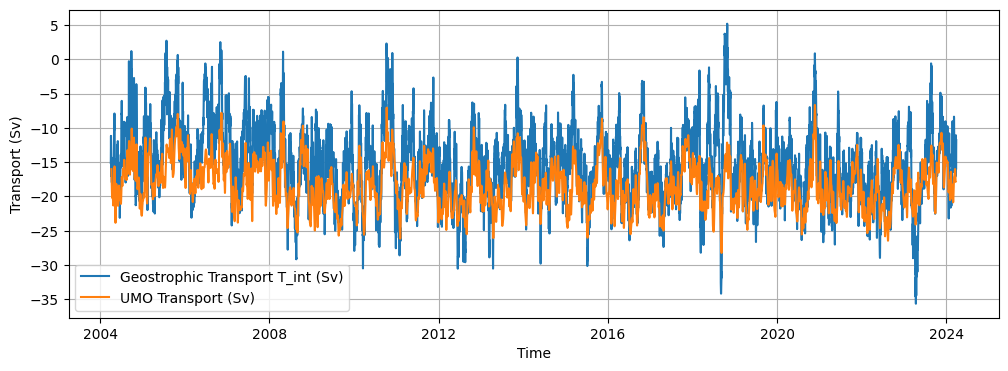

In [88]:
plt.figure(figsize=(12, 4))
plt.plot(T_int.TIME, T_int, label="Geostrophic Transport T_int (Sv)")
plt.plot(moc.TIME, moc.TRANS_UMO, label="UMO Transport (Sv)")
plt.ylabel("Transport (Sv)")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.savefig("../figures/Tint_vs_UMO.png", dpi=300, bbox_inches="tight")

In [89]:
moc.TRANS_UMO.mean()
ampumo = moc.TRANS_UMO.max() - moc.TRANS_UMO.min()
print(f"Mean UMO transport: {moc.TRANS_UMO.mean():.2f} Sv")
print(f"Amplitude of UMO transport: {ampumo:.2f} Sv")

Mean UMO transport: -18.37 Sv
Amplitude of UMO transport: 21.59 Sv


In [90]:
T_int.mean()
ampint = T_int.max() - T_int.min()
print(f"Mean interior geostrophic transport: {T_int.mean():.2f} Sv")
print(f"Amplitude of interior geostrophic transport: {ampint:.2f} Sv")

Mean interior geostrophic transport: -15.24 Sv
Amplitude of interior geostrophic transport: 40.83 Sv


In [91]:
# Match the time axes and remove non-finite points
moc_umo = moc.TRANS_UMO
dt_days = 0.5

T_int, moc_umo = xr.align(T_int, moc_umo, join="inner")
mask = np.isfinite(T_int.values) & np.isfinite(moc_umo.values)
T_int = T_int.isel(TIME=mask)
moc_umo = moc_umo.isel(TIME=mask)

dt_years = dt_days / 365.25
print(f"RAPID sample spacing: {dt_days:.2f} days (~{dt_years:.3f} years)")

RAPID sample spacing: 0.50 days (~0.001 years)


In [92]:
# Part 1: correlation and regression of T_int vs. TRANS_UMO
stats = timeseries.compare_series(T_int, moc_umo)
print(f"Pearson r = {stats['pearson_r']:.3f}")
print(f"Lag at peak correlation = {stats['lag']} samples")

# Linear regression T_int ~ a + b * TRANS_UMO
slope, intercept = np.polyfit(moc_umo.values, T_int.values, 1)
print(f"Linear fit: T_int = {slope:.3f} * TRANS_UMO + {intercept:.3f}")

Peak cross-correlation at lag -1, if negative: x leads y
Pearson r = 0.767
Lag at peak correlation = -1 samples
Linear fit: T_int = 1.206 * TRANS_UMO + 6.913


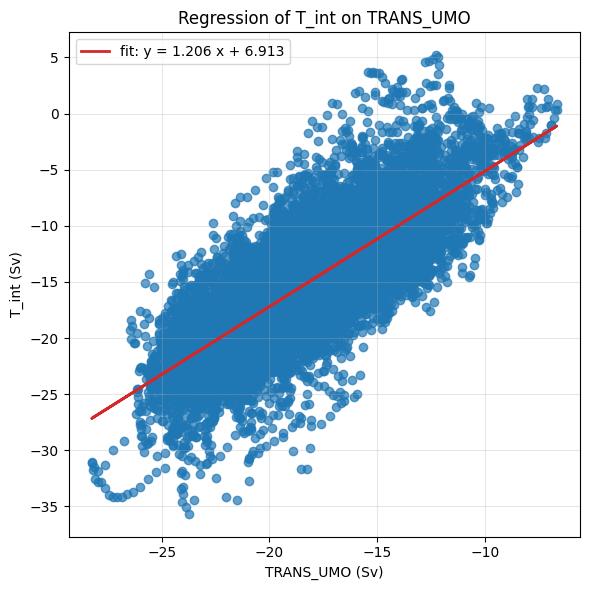

In [93]:
fig, ax = plot_regression_scatter(
    moc_umo.values,
    T_int.values,
    slope=slope,
    intercept=intercept,
    x_label="TRANS_UMO (Sv)",
    y_label="T_int (Sv)",
    title="Regression of T_int on TRANS_UMO",
)
plt.savefig("../figures/regression_Tint_vs_umo.png", dpi=300, bbox_inches="tight")
plt.show()

# PART 2

## Evaluating time series

In [94]:
rapid = ds[0]

## Seasonality

### MOC

In [95]:
moc = rapid.MOC
moc_deseason = seasonal.remove_seasonal_cycle(moc)
moc_seasonal = seasonal.seasonal_climatology(moc)

# ensure moc contains no NaN values before detrending
moc_finite = moc[~np.isnan(moc)]
moc_detrend = scipy.signal.detrend(moc_finite, type="linear")
moc_detr = xr.DataArray(moc_detrend, coords=[moc.TIME[~np.isnan(moc)]], dims=["TIME"])

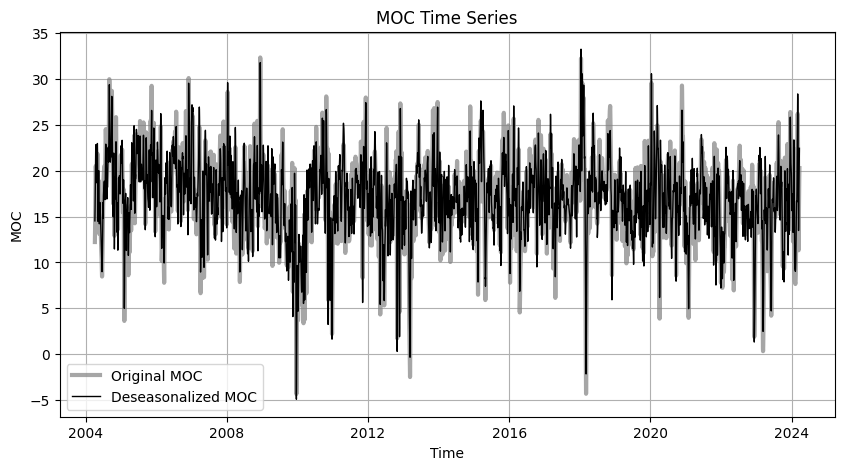

In [96]:
plt.figure(figsize=(10, 5))
plt.plot(moc.TIME, moc, alpha=0.7, label="Original MOC", linewidth=3, color="gray")
plt.plot(
    moc_deseason.TIME,
    moc_deseason,
    label="Deseasonalized MOC",
    color="black",
    linewidth=1,
)
plt.title("MOC Time Series")
plt.xlabel("Time")
plt.ylabel("MOC")
plt.grid()
plt.legend()
plt.savefig(
    "../figures/moc_time_series_with_deseasonalized.png", dpi=300, bbox_inches="tight"
)

### UMO

In [97]:
umo = rapid.TRANS_UMO
umo_deseason = seasonal.remove_seasonal_cycle(umo)

umo_finite = umo[~np.isnan(umo)]
umo_detrend = scipy.signal.detrend(umo_finite)
umo_detr = xr.DataArray(umo_detrend, coords=[umo.TIME[~np.isnan(umo)]], dims=["TIME"])

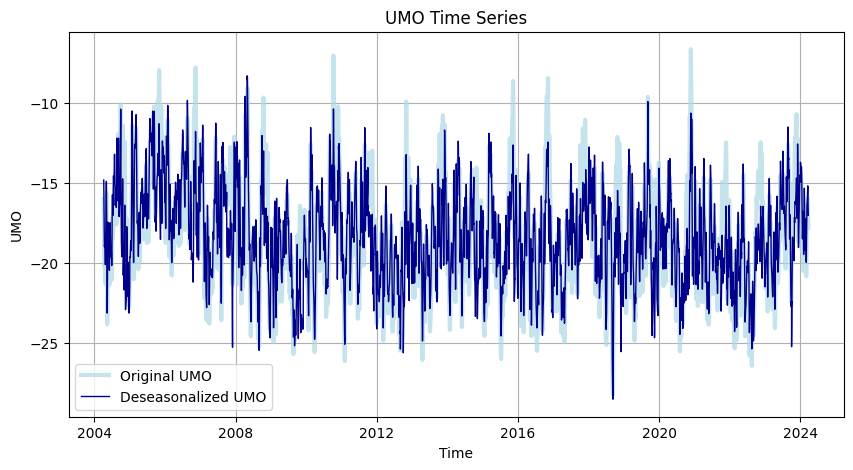

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(umo.TIME, umo, alpha=0.7, label="Original UMO", linewidth=3, color="lightblue")
plt.plot(
    umo_deseason.TIME,
    umo_deseason,
    label="Deseasonalized UMO",
    color="darkblue",
    linewidth=1,
)
plt.title("UMO Time Series")
plt.xlabel("Time")
plt.grid()
plt.ylabel("UMO")
plt.legend()
plt.savefig(
    "../figures/umo_time_series_with_deseasonalized.png", dpi=300, bbox_inches="tight"
)

## Autocorrelation

### MOC

In [99]:
importlib.reload(correlation)

<module 'correlation_trends.correlation' from 'C:\\Users\\Isabelle\\Documents\\GitHub\\data_analysis-assignment\\correlation_trends\\correlation.py'>

In [100]:
autocorr_moc = correlation.autocorr(moc_detr, biased=True)
integral_timescale_moc = correlation.integral_timescale(moc_detr, dt=dt_days)
index_moc = correlation.integral_timescale_i(moc_detr, dt=dt_days, biased=True)
effective_dof_moc = correlation.effective_dof(moc_detr, dt=dt_days)
effective_dof_moc_new = correlation.effective_dof_new(moc_detr, dt=dt_days)

In [101]:
effective_dof_moc, effective_dof_moc_new, integral_timescale_moc, index_moc

(196.8866241896308, np.float64(196.88556636957958), 18.511922864244802, 222)

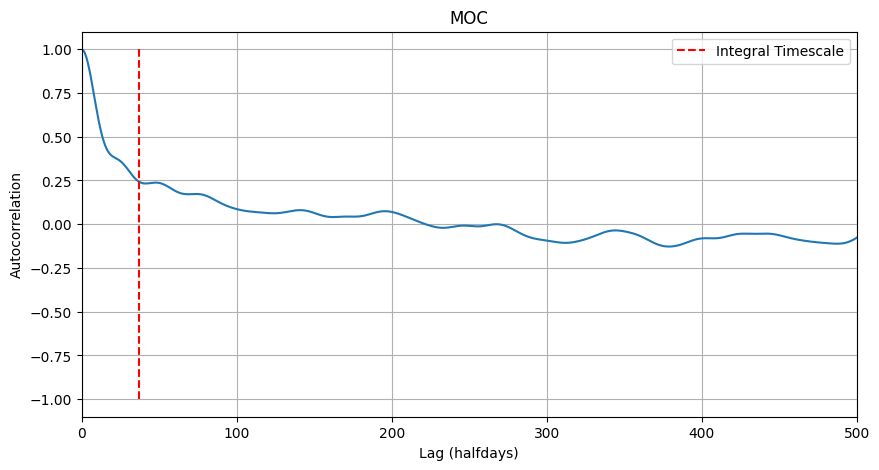

In [102]:
plt.figure(figsize=(10, 5))
plt.plot(autocorr_moc)

plt.xlim(0, 500)
plt.vlines(
    [integral_timescale_moc * 2],
    ymin=-1,
    ymax=1,
    color="red",
    linestyle="--",
    label="Integral Timescale",
)
plt.xlabel("Lag (halfdays)")

plt.ylabel("Autocorrelation")
plt.title("MOC")
plt.grid()
plt.legend()
plt.show()

In [103]:
print(f"Integral timescale for MOC: {integral_timescale_moc:.2f} days")
print(f"Effective degrees of freedom for MOC: {effective_dof_moc:.2f}")

Integral timescale for MOC: 18.51 days
Effective degrees of freedom for MOC: 196.89


### UMO

In [104]:
autocorr_umo = correlation.autocorr(umo_detr)
integral_timescale_umo = correlation.integral_timescale(umo_detr, dt=dt_days)
effective_dof_umo = correlation.effective_dof(umo_detr, dt=dt_days)

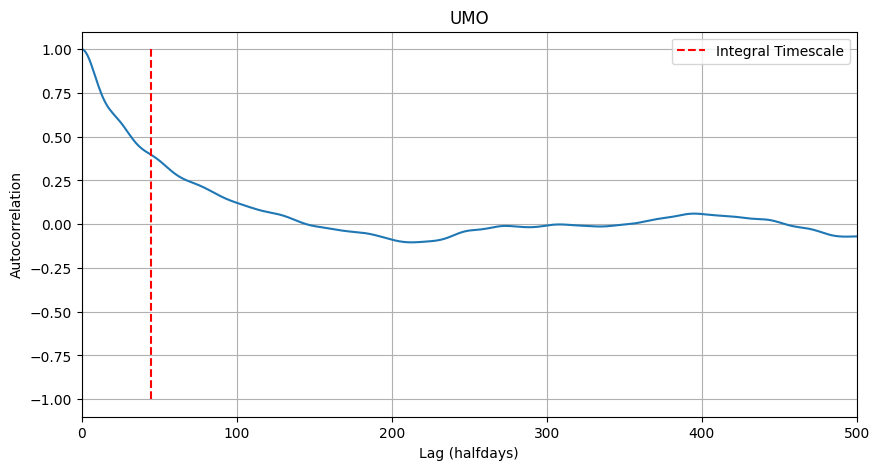

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(autocorr_umo)
plt.xlim(0, 500)
plt.vlines(
    [integral_timescale_umo * 2],
    ymin=-1,
    ymax=1,
    color="red",
    linestyle="--",
    label="Integral Timescale",
)
plt.xlabel("Lag (halfdays)")
plt.ylabel("Autocorrelation")
plt.title("UMO")
plt.grid()
plt.legend()
plt.show()

In [106]:
autocorr_umo = correlation.autocorr(umo_detr)
integral_timescale_umo = correlation.integral_timescale(umo_detr, dt=dt_days)
effective_dof_umo = correlation.effective_dof(umo_detr, dt=dt_days)
print(f"Integral timescale for UMO: {integral_timescale_umo:.2f} days")
print(f"Effective degrees of freedom for UMO: {effective_dof_umo:.2f}")

Integral timescale for UMO: 22.52 days
Effective degrees of freedom for UMO: 161.87


## Linear trend

In [107]:
importlib.reload(trends)

<module 'correlation_trends.trends' from 'C:\\Users\\Isabelle\\Documents\\GitHub\\data_analysis-assignment\\correlation_trends\\trends.py'>

### MOC

In [108]:
from correlation_trends.trends import TrendResult

TrendResult = trends.trend_with_significance(moc_finite.TIME, moc_finite, dt=dt_days)

In [109]:
TrendResult

TrendResult(slope=-3.0105198853684488e-18, intercept=21.180148524037264, se=1.9896963756038644e-19, se_eff=1.7121575969677352e-18, p_naive=2.4982297822367372e-51, p_eff=0.08026287916797091, n_eff=196.88556636957955, t_naive=-15.130549174643638, t_eff=-1.7583193805874755)

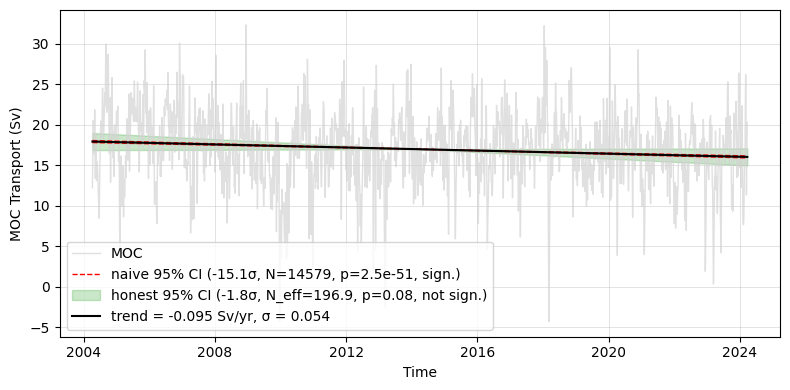

In [ ]:
t0 = moc_finite.TIME.values[0]
t_days = (moc_finite.TIME.values - t0) / np.timedelta64(1, "D")
t_bar = t_days.mean()

tr = trends.trend_with_significance(t_days, moc_finite.values, dt=dt_days)

yr = 365.25
slope_yr = tr.slope * yr
se_yr = tr.se * yr
se_eff_yr = tr.se_eff * yr

time_dt = moc_finite.TIME.values
y = moc_finite.values
time_years = t_days / yr

trend_line = tr.intercept + slope_yr * time_years

# distance from the *center* of the record, in years — this is what SE scales with
dt_years = (t_days - t_bar) / yr

naive_halfwidth = 1.96 * se_yr * np.abs(dt_years)
eff_halfwidth = 1.96 * se_eff_yr * np.abs(dt_years)

naive_upper, naive_lower = trend_line + naive_halfwidth, trend_line - naive_halfwidth
eff_upper, eff_lower = trend_line + eff_halfwidth, trend_line - eff_halfwidth

N = len(moc_finite)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(time_dt, y, label="MOC", color="lightgray", alpha=0.7, linewidth=1)

# naive band — dashed red outline, light fill
ax.fill_between(time_dt, naive_lower, naive_upper, color="tab:red", alpha=0.10)
ax.plot(
    time_dt,
    naive_upper,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"naive 95% CI ({tr.t_naive:.1f}σ, N={N}, p={tr.p_naive:.1e}, sign.)",
)
ax.plot(time_dt, naive_lower, color="red", linestyle="--", linewidth=1)

# honest band — solid blue fill, no outline needed
ax.fill_between(
    time_dt,
    eff_lower,
    eff_upper,
    color="tab:green",
    alpha=0.25,
    label=f"honest 95% CI ({tr.t_eff:.1f}σ, N_eff={tr.n_eff:.1f}, p={tr.p_eff:.2f}, not sign.)", ## threshold p = 0.05
)

# trend line (same for both — slope is identical, only uncertainty differs)
ax.plot(
    time_dt,
    trend_line,
    color="k",
    linewidth=1.5,
    label=f"trend = {slope_yr:.3f} Sv/yr, σ = {se_eff_yr:.3f}",
)

ax.set_xlabel("Time")
ax.set_ylabel("MOC Transport (Sv)")
ax.grid(alpha=0.5, linewidth=0.5)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.savefig("../figures/moc_trend_with_significance.png", dpi=300, bbox_inches="tight")
plt.show()

In [111]:
umo_finite.size

14579

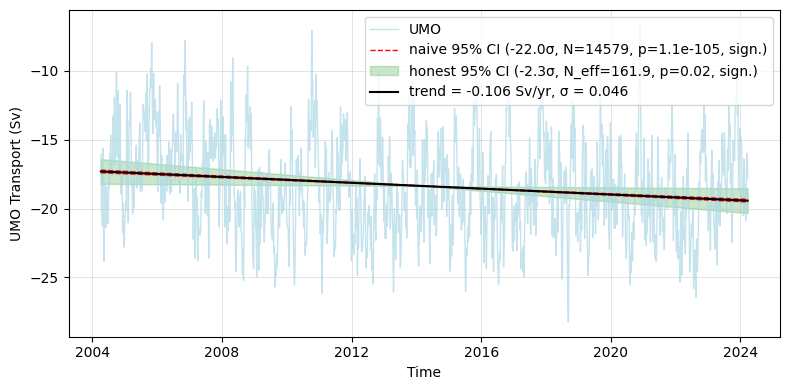

In [ ]:
t0 = umo_finite.TIME.values[0]
t_days = (umo_finite.TIME.values - t0) / np.timedelta64(1, "D")
t_bar = t_days.mean()

tr = trends.trend_with_significance(t_days, umo_finite.values, dt=dt_days)

yr = 365.25
slope_yr = tr.slope * yr
se_yr = tr.se * yr
se_eff_yr = tr.se_eff * yr

time_dt = umo_finite.TIME.values
y = umo_finite.values
time_years = t_days / yr

trend_line = tr.intercept + slope_yr * time_years

# distance from the *center* of the record, in years — this is what SE scales with
dt_years = (t_days - t_bar) / yr

naive_halfwidth = 1.96 * se_yr * np.abs(dt_years)
eff_halfwidth = 1.96 * se_eff_yr * np.abs(dt_years)

naive_upper, naive_lower = trend_line + naive_halfwidth, trend_line - naive_halfwidth
eff_upper, eff_lower = trend_line + eff_halfwidth, trend_line - eff_halfwidth

N = len(umo_finite)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(time_dt, y, label="UMO", color="lightblue", alpha=0.7, linewidth=1)

# naive band — dashed red outline, light fill
ax.fill_between(time_dt, naive_lower, naive_upper, color="tab:red", alpha=0.10)
ax.plot(
    time_dt,
    naive_upper,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"naive 95% CI ({tr.t_naive:.1f}σ, N={N}, p={tr.p_naive:.1e}, sign.)",
)
ax.plot(time_dt, naive_lower, color="red", linestyle="--", linewidth=1)

# honest band — solid blue fill, no outline needed
ax.fill_between(
    time_dt,
    eff_lower,
    eff_upper,
    color="tab:green",
    alpha=0.25,
    label=f"honest 95% CI ({tr.t_eff:.1f}σ, N_eff={tr.n_eff:.1f}, p={tr.p_eff:.2f}, sign.)", ### threshold p = 0.05
)

# trend line (same for both — slope is identical, only uncertainty differs)
ax.plot(
    time_dt,
    trend_line,
    color="k",
    linewidth=1.5,
    label=f"trend = {slope_yr:.3f} Sv/yr, σ = {se_eff_yr:.3f}",
)

ax.set_xlabel("Time")
ax.set_ylabel("UMO Transport (Sv)")
ax.grid(alpha=0.5, linewidth=0.5)
ax.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.savefig("../figures/umo_trend_with_significance.png", dpi=300, bbox_inches="tight")
plt.show()

## Cross-correlation and lead/lag

### which datasets do i want to use?

In [113]:
osnap = amocatlas.read.osnap()
dso = amocatlas.read.dso()
fbc = amocatlas.read.fbc()

Loading 1 OSNAP dataset(s):
  0. OSNAP_MOC_MHT_MFT_TimeSeries_201408_202207_2025.nc: Time series of MOC, MHT, and MFT (2014-2022)

Loading 1 Denmark Strait Overflow dataset(s):
  0. DSO_transport_hourly_1996_2021.nc: Overflow time-series through Denmark Strait

Loading 1 Faroe Bank Channel dataset(s):
  0. OS_GSR_FBC_D_1995_2024.nc: Daily average of FBC overflow transport, estimated from an array of moored ADCPs in Sv



(np.float64(16283.5), np.float64(19174.5))

<Figure size 1200x400 with 0 Axes>

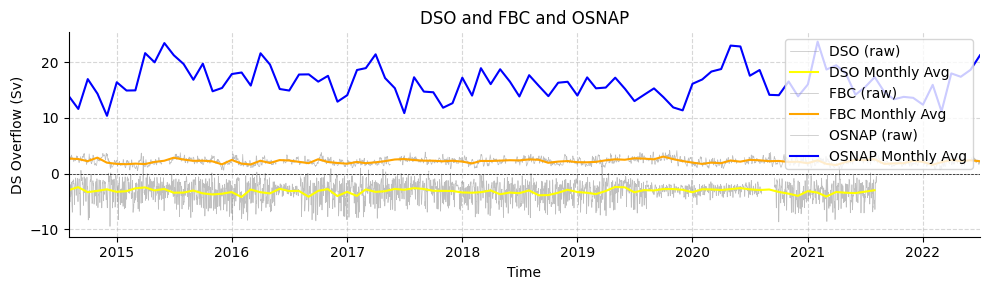

In [114]:
plt.figure(figsize=(12, 4))
amocatlas.plotters.plot_amoc_timeseries(
    data=[dso, fbc, osnap],
    varnames=["TRANS_DSO", "TRANS_FBC", "MOC_EAST_SIGMA0"],
    labels=["DSO", "FBC", "OSNAP"],
    resample_monthly=True,
    plot_raw=True,
    colors=["yellow", "orange", "blue"],
    title="DSO and FBC and OSNAP",
)
plt.xlim([osnap.TIME.values[0], osnap.TIME.values[-1]])

In [115]:
rapid = rapid
move = amocatlas.read.move()
lebras35n = amocatlas.read.lebras35n()
wh41n = amocatlas.read.wh41n()

Loading 1 MOVE 16°N dataset(s):
  0. OS_MOVE_20000206-20221014_DPR_VOLUMETRANSPORT.nc: MOVE transport time series



C:\Users\Isabelle\Documents\GitHub\AMOCatlas\amocatlas\data_sources\move16n.py:156: RuntimeWarning: invalid value encountered in multiply
  time_converted = base + clean_time * np.timedelta64(1, "D")
C:\Users\Isabelle\Documents\GitHub\AMOCatlas\amocatlas\standardise.py:1789: UserWarning: Metadata conflict for 'date_created': original file='2025-04-23T01:35:26Z' vs array-level YAML='2019-01-30T18:13:16Z'; keeping original file (date mismatch).
  resolved_value = resolve_metadata_conflict(


Loading 1 Le Bras et al. 2023 at 35°N dataset(s):
  0. AMOC35N.nc: AMOC transport data at 35°N

Loading 1 Willis & Hobbs 41°N dataset(s):
  0. hobbs_willis_amoc41N_tseries.txt: Transport time series of Ekman volume, Northward geostrophc, Meridional Overturning volume and Meridional Overturning Heat



(<Figure size 1000x300 with 1 Axes>,
 <Axes: title={'center': 'LEBRAS 35°N and RAPID 26°N and WH 41°N'}, xlabel='Time', ylabel='MOC$_{z}$ (Sv)'>)

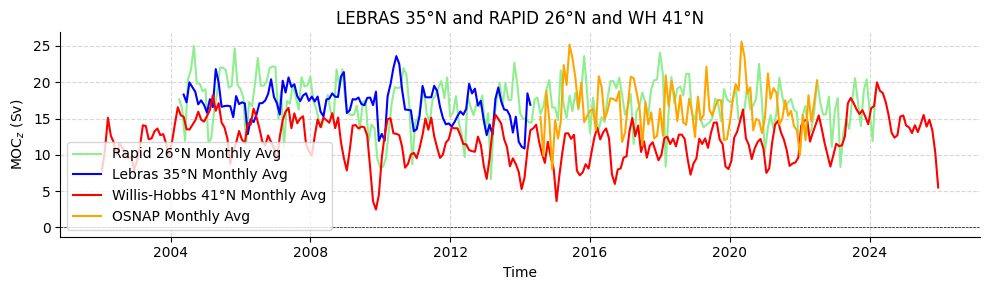

In [116]:
# Plot MOVE timeseries
amocatlas.plotters.plot_amoc_timeseries(
    data=[rapid, lebras35n, wh41n, osnap],
    varnames=["MOC", "MOC_SIGMA2", "MOC", "MOC_SIGMA0"],
    labels=["Rapid 26°N", "Lebras 35°N", "Willis-Hobbs 41°N", "OSNAP"],
    colors=["lightgreen", "blue", "red", "orange"],
    resample_monthly=True,
    plot_raw=False,
    title="LEBRAS 35°N and RAPID 26°N and WH 41°N",
)
# plt.xlim([lebras35n.TIME.values[0], lebras35n.TIME.values[-1]])

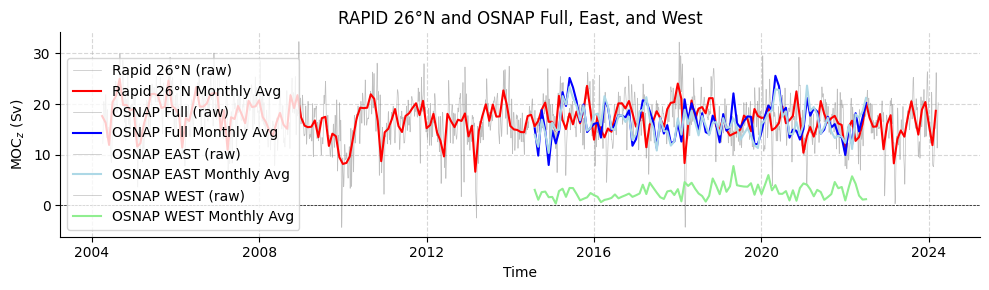

In [117]:
amocatlas.plotters.plot_amoc_timeseries(
    data=[rapid, osnap, osnap, osnap],
    varnames=["MOC", "MOC_SIGMA0", "MOC_EAST_SIGMA0", "MOC_WEST_SIGMA0"],
    labels=["Rapid 26°N", "OSNAP Full", "OSNAP EAST", "OSNAP WEST"],
    colors=["red", "blue", "lightblue", "lightgreen"],
    resample_monthly=True,
    plot_raw=True,
    title="RAPID 26°N and OSNAP Full, East, and West",
)
plt.savefig(
    "../figures/rapid_osnap_comparison_full_length.png", dpi=300, bbox_inches="tight"
)

### Let's compare OSNAP and RAPID 
first OSNAP total and maybe later compare east with rapid and west with rapid separately

In [118]:
osnapmoc = osnap.MOC_SIGMA0
osnapeastmoc = osnap.MOC_EAST_SIGMA0
osnapwestmoc = osnap.MOC_WEST_SIGMA0
rapidmoc = rapid.MOC

In [119]:
osnapmoc_deseason = seasonal.remove_seasonal_cycle(osnapmoc)
rapidmoc_deseason = seasonal.remove_seasonal_cycle(rapidmoc)

### general deseasonalizing code 

In [120]:
importlib.reload(seasonal)

<module 'correlation_trends.seasonal' from 'C:\\Users\\Isabelle\\Documents\\GitHub\\data_analysis-assignment\\correlation_trends\\seasonal.py'>

In [121]:
osnapmoc_deseason, osnapmoc_clim = seasonal.deseasonalize(osnapmoc)
rapidmoc_deseason, rapidmoc_clim = seasonal.deseasonalize(
    rapidmoc
)  # use the aligned/monthly version

### general alignment code 

In [122]:
importlib.reload(timeseries)

<module 'correlation_trends.timeseries' from 'C:\\Users\\Isabelle\\Documents\\GitHub\\data_analysis-assignment\\correlation_trends\\timeseries.py'>

In [123]:
# example usage
#
osnapmoc_a, rapidmoc_a = timeseries.align_timeseries(osnapmoc, rapidmoc)
osnapmoc_deseason_a, rapidmoc_deseason_a = timeseries.align_timeseries(
    osnapmoc_deseason, rapidmoc_deseason
)

Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)
Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)


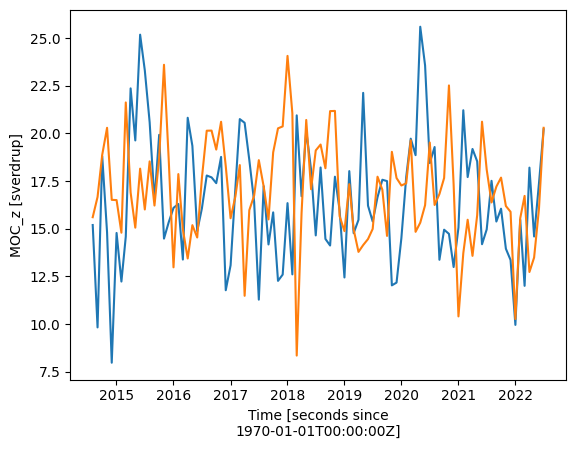

In [124]:
osnapmoc_a.plot()
rapidmoc_a.plot()

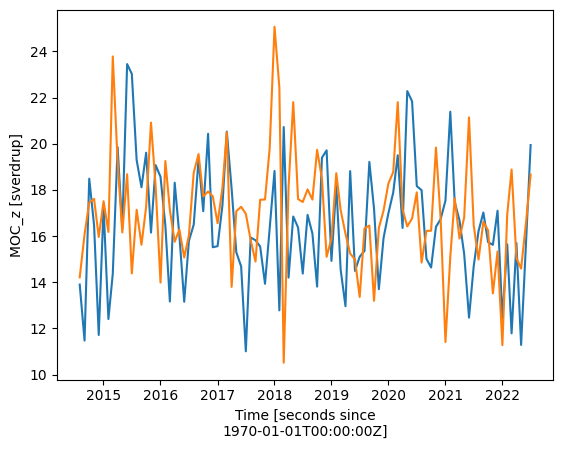

In [125]:
osnapmoc_deseason_a.plot()
rapidmoc_deseason_a.plot()

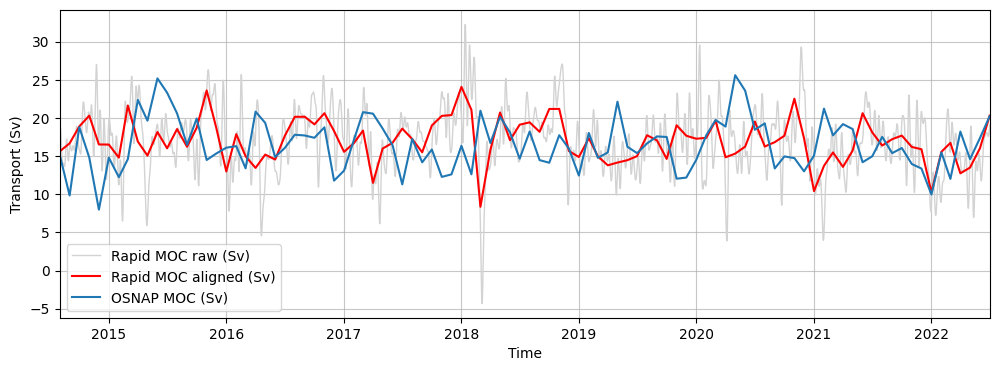

In [126]:
plt.figure(figsize=(12, 4))
plt.plot(
    rapidmoc.TIME, rapidmoc, label="Rapid MOC raw (Sv)", color="lightgray", linewidth=1
)
plt.plot(rapidmoc_a.TIME, rapidmoc_a, label="Rapid MOC aligned (Sv)", color="red")
plt.plot(osnapmoc.TIME, osnapmoc, label="OSNAP MOC (Sv)")
plt.ylabel("Transport (Sv)")
plt.xlabel("Time")
plt.xlim([osnapmoc.TIME.values[0], osnapmoc.TIME.values[-1]])
plt.legend()
plt.grid(alpha=0.7)
plt.savefig(
    "../figures/osnap_rapid_moc_timeseries-show-filter.png",
    dpi=300,
    bbox_inches="tight",
)

### cross-correlate

In [127]:
importlib.reload(correlation)

<module 'correlation_trends.correlation' from 'C:\\Users\\Isabelle\\Documents\\GitHub\\data_analysis-assignment\\correlation_trends\\correlation.py'>

Peak cross-correlation at lag -4, if negative: x leads y
Peak cross-correlation at lag 3, if negative: x leads y


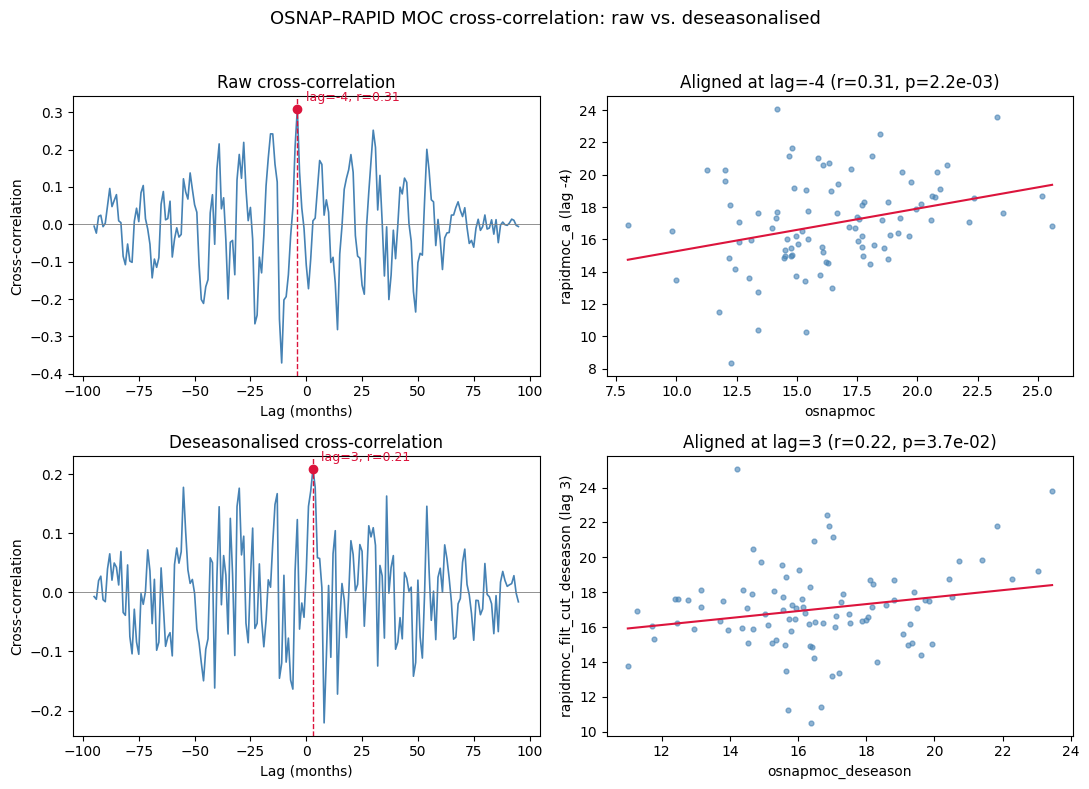

In [128]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

correlation.plot_cc_panel(
    axes[0, 0],
    axes[0, 1],
    osnapmoc_a,
    rapidmoc_a,
    "Raw cross-correlation",
    "osnapmoc",
    "rapidmoc_a",
)

correlation.plot_cc_panel(
    axes[1, 0],
    axes[1, 1],
    osnapmoc_deseason_a,
    rapidmoc_deseason_a,
    "Deseasonalised cross-correlation",
    "osnapmoc_deseason",
    "rapidmoc_filt_cut_deseason",
)

fig.suptitle("OSNAP–RAPID MOC cross-correlation: raw vs. deseasonalised", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(
    "../figures/osnap_rapid_moc_cross_correlation.png", dpi=300, bbox_inches="tight"
)
plt.show()

In [129]:
# OSNAP
autocorr_osnap = correlation.autocorr(osnapmoc_deseason_a)
integral_timescale_osnap = correlation.integral_timescale(
    osnapmoc_deseason_a, dt=dt_days
)
effective_dof_osnap = correlation.effective_dof(osnapmoc_deseason_a, dt=dt_days)
print(f"Integral timescale for OSNAP: {integral_timescale_osnap:.2f} months")
print(f"Effective degrees of freedom for OSNAP: {effective_dof_osnap:.2f}")

Integral timescale for OSNAP: 0.48 months
Effective degrees of freedom for OSNAP: 50.07


In [130]:
# OSNAP
autocorr_osnap_raw = correlation.autocorr(osnapmoc_a)
integral_timescale_osnap_raw = correlation.integral_timescale(osnapmoc_a, dt=dt_days)
effective_dof_osnap_raw = correlation.effective_dof(osnapmoc_a, dt=dt_days)
print(f"Integral timescale for OSNAP: {integral_timescale_osnap_raw:.2f} months")
print(f"Effective degrees of freedom for OSNAP: {effective_dof_osnap_raw:.2f}")

Integral timescale for OSNAP: 0.53 months
Effective degrees of freedom for OSNAP: 45.62


In [131]:
# osnap detrended
osnapmoc_a_finite = osnapmoc_a[~np.isnan(osnapmoc_a)]
osnap_detrend = scipy.signal.detrend(osnapmoc_a_finite)
osnap_detr = xr.DataArray(
    osnap_detrend, coords=[osnapmoc_a.TIME[~np.isnan(osnapmoc_a)]], dims=["TIME"]
)

autocorr_osnap_detrend = correlation.autocorr(osnap_detr)
integral_timescale_osnap_detrend = correlation.integral_timescale(
    osnap_detr, dt=dt_days
)
effective_dof_osnap_detrend = correlation.effective_dof(osnap_detr, dt=dt_days)
print(
    f"Integral timescale for OSNAP (detrended): {integral_timescale_osnap_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for OSNAP (detrended): {effective_dof_osnap_detrend:.2f}"
)

Integral timescale for OSNAP (detrended): 0.52 months
Effective degrees of freedom for OSNAP (detrended): 46.02


In [132]:
# osnap deseasonalized and detrended
osnapmoc_deseason_a_finite = osnapmoc_deseason_a[~np.isnan(osnapmoc_deseason_a)]
osnap_deseason_detrend = scipy.signal.detrend(osnapmoc_deseason_a_finite)
osnap_deseason_detr = xr.DataArray(
    osnap_deseason_detrend,
    coords=[osnapmoc_deseason_a.TIME[~np.isnan(osnapmoc_deseason_a)]],
    dims=["TIME"],
)
autocorr_osnap_deseason_detrend = correlation.autocorr(osnap_deseason_detr)
integral_timescale_osnap_deseason_detrend = correlation.integral_timescale(
    osnap_deseason_detr, dt=dt_days
)
effective_dof_osnap_deseason_detrend = correlation.effective_dof(
    osnap_deseason_detr, dt=dt_days
)
print(
    f"Integral timescale for OSNAP (deseasonalized and detrended): {integral_timescale_osnap_deseason_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for OSNAP (deseasonalized and detrended): {effective_dof_osnap_deseason_detrend:.2f}"
)

Integral timescale for OSNAP (deseasonalized and detrended): 0.46 months
Effective degrees of freedom for OSNAP (deseasonalized and detrended): 51.98


In [133]:
# RAPID
autocorr_rapid = correlation.autocorr(rapidmoc_deseason_a)
integral_timescale_rapid = correlation.integral_timescale(
    rapidmoc_deseason_a, dt=dt_days
)
effective_dof_rapid = correlation.effective_dof(rapidmoc_deseason_a, dt=dt_days)
print(f"Integral timescale for RAPID: {integral_timescale_rapid:.2f} months")
print(f"Effective degrees of freedom for RAPID: {effective_dof_rapid:.2f}")

Integral timescale for RAPID: 0.30 months
Effective degrees of freedom for RAPID: 80.47


In [134]:
# RAPID
autocorr_rapid_raw = correlation.autocorr(rapidmoc_a)
integral_timescale_rapid_raw = correlation.integral_timescale(rapidmoc_a, dt=dt_days)
effective_dof_rapid_raw = correlation.effective_dof(rapidmoc_a, dt=dt_days)
print(f"Integral timescale for RAPID: {integral_timescale_rapid_raw:.2f} months")
print(f"Effective degrees of freedom for RAPID: {effective_dof_rapid_raw:.2f}")

Integral timescale for RAPID: 0.36 months
Effective degrees of freedom for RAPID: 66.76


In [135]:
# rapid detrended
rapidmoc_a_finite = rapidmoc_a[~np.isnan(rapidmoc_a)]
rapid_detrend = scipy.signal.detrend(rapidmoc_a_finite)
rapid_detr = xr.DataArray(
    rapid_detrend, coords=[rapidmoc_a.TIME[~np.isnan(rapidmoc_a)]], dims=["TIME"]
)

autocorr_rapid_detrend = correlation.autocorr(rapid_detr)
integral_timescale_rapid_detrend = correlation.integral_timescale(
    rapid_detr, dt=dt_days
)
effective_dof_rapid_detrend = correlation.effective_dof(rapid_detr, dt=dt_days)
print(
    f"Integral timescale for rapid (detrended): {integral_timescale_rapid_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for rapid (detrended): {effective_dof_rapid_detrend:.2f}"
)

Integral timescale for rapid (detrended): 0.33 months
Effective degrees of freedom for rapid (detrended): 72.13


In [136]:
# rapid deseasonalized and detrended
rapidmoc_deseason_a_finite = rapidmoc_deseason_a[~np.isnan(rapidmoc_deseason_a)]
rapid_deseason_detrend = scipy.signal.detrend(rapidmoc_deseason_a_finite)
rapid_deseason_detr = xr.DataArray(
    rapid_deseason_detrend,
    coords=[rapidmoc_deseason_a.TIME[~np.isnan(rapidmoc_deseason_a)]],
    dims=["TIME"],
)
autocorr_rapid_deseason_detrend = correlation.autocorr(rapid_deseason_detr)
integral_timescale_rapid_deseason_detrend = correlation.integral_timescale(
    rapid_deseason_detr, dt=dt_days
)
effective_dof_rapid_deseason_detrend = correlation.effective_dof(
    rapid_deseason_detr, dt=dt_days
)
print(
    f"Integral timescale for rapid (deseasonalized and detrended): {integral_timescale_rapid_deseason_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for rapid (deseasonalized and detrended): {effective_dof_rapid_deseason_detrend:.2f}"
)

Integral timescale for rapid (deseasonalized and detrended): 0.27 months
Effective degrees of freedom for rapid (deseasonalized and detrended): 88.52


In [137]:
# first detrend and then deseasonalize
# osnap detrended data: osnap_detr
# rapid detrended data: rapid_detr
osnapmoc_detr2_deseason, osnapmoc_clim_detr2 = seasonal.deseasonalize(osnap_detr)
rapidmoc_detr2_deseason, rapidmoc_clim_detr2 = seasonal.deseasonalize(rapid_detr)

Peak cross-correlation at lag -4, if negative: x leads y
Peak cross-correlation at lag 3, if negative: x leads y
Peak cross-correlation at lag -4, if negative: x leads y
Peak cross-correlation at lag 3, if negative: x leads y
Peak cross-correlation at lag 3, if negative: x leads y


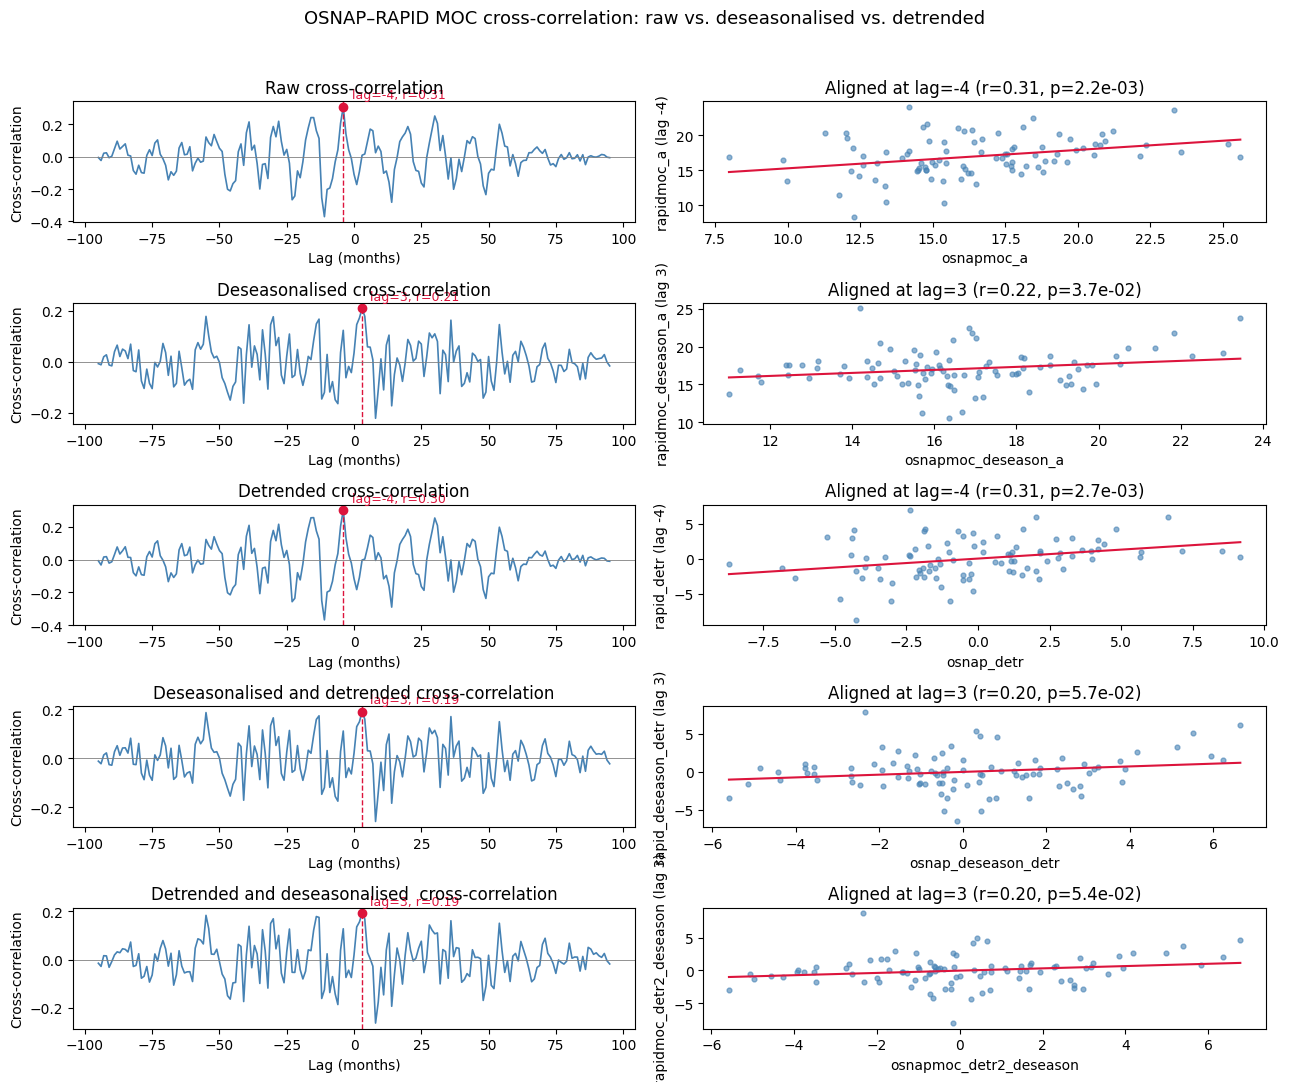

In [138]:
fig, axes = plt.subplots(5, 2, figsize=(13, 11))

correlation.plot_cc_panel(
    axes[0, 0],
    axes[0, 1],
    osnapmoc_a,
    rapidmoc_a,
    "Raw cross-correlation",
    "osnapmoc_a",
    "rapidmoc_a",
)

correlation.plot_cc_panel(
    axes[1, 0],
    axes[1, 1],
    osnapmoc_deseason_a,
    rapidmoc_deseason_a,
    "Deseasonalised cross-correlation",
    "osnapmoc_deseason_a",
    "rapidmoc_deseason_a",
)
correlation.plot_cc_panel(
    axes[2, 0],
    axes[2, 1],
    osnap_detr,
    rapid_detr,
    "Detrended cross-correlation",
    "osnap_detr",
    "rapid_detr",
)
correlation.plot_cc_panel(
    axes[3, 0],
    axes[3, 1],
    osnap_deseason_detr,
    rapid_deseason_detr,
    "Deseasonalised and detrended cross-correlation",
    "osnap_deseason_detr",
    "rapid_deseason_detr",
)
correlation.plot_cc_panel(
    axes[4, 0],
    axes[4, 1],
    osnapmoc_detr2_deseason,
    rapidmoc_detr2_deseason,
    "Detrended and deseasonalised  cross-correlation",
    "osnapmoc_detr2_deseason",
    "rapidmoc_detr2_deseason",
)
fig.suptitle(
    "OSNAP–RAPID MOC cross-correlation: raw vs. deseasonalised vs. detrended",
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(
    "../figures/osnap_rapid_moc_cross_correlation_deseason_detrend.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## now do the same analysis for opsnap west and rapid and osnap east and rapid

In [139]:
osnapmoc = osnap.MOC_SIGMA0
osnapeastmoc = osnap.MOC_EAST_SIGMA0
osnapwestmoc = osnap.MOC_WEST_SIGMA0
rapidmoc = rapid.MOC

In [140]:
osnapmoc_deseason, osnapmoc_clim = seasonal.deseasonalize(osnapmoc)
osnapeastmoc_deseason, osnapeastmoc_clim = seasonal.deseasonalize(osnapeastmoc)
osnapwestmoc_deseason, osnapwestmoc_clim = seasonal.deseasonalize(osnapwestmoc)
rapidmoc_deseason, rapidmoc_clim = seasonal.deseasonalize(rapidmoc)

In [141]:
osnapmoc_a, rapidmoc_a = timeseries.align_timeseries(osnapmoc, rapidmoc)
osnapeastmoc_a, rapidmoc_a = timeseries.align_timeseries(osnapeastmoc, rapidmoc)
osnapwestmoc_a, rapidmoc_a = timeseries.align_timeseries(osnapwestmoc, rapidmoc)
osnapmoc_deseason_a, rapidmoc_deseason_a = timeseries.align_timeseries(
    osnapmoc_deseason, rapidmoc_deseason
)
osnapeastmoc_deseason_a, rapidmoc_deseason_a = timeseries.align_timeseries(
    osnapeastmoc_deseason, rapidmoc_deseason
)
osnapwestmoc_deseason_a, rapidmoc_deseason_a = timeseries.align_timeseries(
    osnapwestmoc_deseason, rapidmoc_deseason
)

Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)
Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)
Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)
Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)
Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)
Resampled finer series (0 days 12:00:00) -> 31 days 00:00:00 (tolerance 15 days 12:00:00); aligned shape: (96,)


In [142]:
osnapmoc_deseason_a_finite = osnapmoc_deseason_a[~np.isnan(osnapmoc_deseason_a)]
osnap_deseason_detrend = scipy.signal.detrend(osnapmoc_deseason_a_finite)
osnap_deseason_detr = xr.DataArray(
    osnap_deseason_detrend,
    coords=[osnapmoc_deseason_a.TIME[~np.isnan(osnapmoc_deseason_a)]],
    dims=["TIME"],
)

osnapeastmoc_deseason_a_finite = osnapeastmoc_deseason_a[
    ~np.isnan(osnapeastmoc_deseason_a)
]
osnapeast_deseason_detrend = scipy.signal.detrend(osnapeastmoc_deseason_a_finite)
osnapeast_deseason_detr = xr.DataArray(
    osnapeast_deseason_detrend,
    coords=[osnapeastmoc_deseason_a.TIME[~np.isnan(osnapeastmoc_deseason_a)]],
    dims=["TIME"],
)

osnapwestmoc_deseason_a_finite = osnapwestmoc_deseason_a[
    ~np.isnan(osnapwestmoc_deseason_a)
]
osnapwest_deseason_detrend = scipy.signal.detrend(osnapwestmoc_deseason_a_finite)
osnapwest_deseason_detr = xr.DataArray(
    osnapwest_deseason_detrend,
    coords=[osnapwestmoc_deseason_a.TIME[~np.isnan(osnapwestmoc_deseason_a)]],
    dims=["TIME"],
)

rapidmoc_deseason_a_finite = rapidmoc_deseason_a[~np.isnan(rapidmoc_deseason_a)]
rapid_deseason_detrend = scipy.signal.detrend(rapidmoc_deseason_a_finite)
rapid_deseason_detr = xr.DataArray(
    rapid_deseason_detrend,
    coords=[rapidmoc_deseason_a.TIME[~np.isnan(rapidmoc_deseason_a)]],
    dims=["TIME"],
)

In [143]:
# osnap deseasonalized and detrended

autocorr_osnap_deseason_detrend = correlation.autocorr(osnap_deseason_detr)
integral_timescale_osnap_deseason_detrend = correlation.integral_timescale(
    osnap_deseason_detr, dt=dt_days
)
effective_dof_osnap_deseason_detrend = correlation.effective_dof(
    osnap_deseason_detr, dt=dt_days
)
print(
    f"Integral timescale for OSNAP (deseasonalized and detrended): {integral_timescale_osnap_deseason_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for OSNAP (deseasonalized and detrended): {effective_dof_osnap_deseason_detrend:.2f}"
)

autocorr_osnapeast_deseason_detrend = correlation.autocorr(osnapeast_deseason_detr)
integral_timescale_osnapeast_deseason_detrend = correlation.integral_timescale(
    osnapeast_deseason_detr, dt=dt_days
)
effective_dof_osnapeast_deseason_detrend = correlation.effective_dof(
    osnapeast_deseason_detr, dt=dt_days
)
print(
    f"Integral timescale for OSNAP East (deseasonalized and detrended): {integral_timescale_osnapeast_deseason_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for OSNAP East(deseasonalized and detrended): {effective_dof_osnapeast_deseason_detrend:.2f}"
)


autocorr_osnapwest_deseason_detrend = correlation.autocorr(osnapwest_deseason_detr)
integral_timescale_osnapwest_deseason_detrend = correlation.integral_timescale(
    osnapwest_deseason_detr, dt=dt_days
)
effective_dof_osnapwest_deseason_detrend = correlation.effective_dof(
    osnapwest_deseason_detr, dt=dt_days
)
print(
    f"Integral timescale for OSNAP West(deseasonalized and detrended): {integral_timescale_osnapwest_deseason_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for OSNAP West(deseasonalized and detrended): {effective_dof_osnapwest_deseason_detrend:.2f}"
)


autocorr_rapid_deseason_detrend = correlation.autocorr(rapid_deseason_detr)
integral_timescale_rapid_deseason_detrend = correlation.integral_timescale(
    rapid_deseason_detr, dt=dt_days
)
effective_dof_rapid_deseason_detrend = correlation.effective_dof(
    rapid_deseason_detr, dt=dt_days
)
print(
    f"Integral timescale for RAPID (deseasonalized and detrended): {integral_timescale_rapid_deseason_detrend:.2f} months"
)
print(
    f"Effective degrees of freedom for RAPID (deseasonalized and detrended): {effective_dof_rapid_deseason_detrend:.2f}"
)

Integral timescale for OSNAP (deseasonalized and detrended): 0.46 months
Effective degrees of freedom for OSNAP (deseasonalized and detrended): 51.98
Integral timescale for OSNAP East (deseasonalized and detrended): 0.61 months
Effective degrees of freedom for OSNAP East(deseasonalized and detrended): 39.65
Integral timescale for OSNAP West(deseasonalized and detrended): 0.71 months
Effective degrees of freedom for OSNAP West(deseasonalized and detrended): 34.02
Integral timescale for RAPID (deseasonalized and detrended): 0.27 months
Effective degrees of freedom for RAPID (deseasonalized and detrended): 88.52


Peak cross-correlation at lag 3, if negative: x leads y
Peak cross-correlation at lag -30, if negative: x leads y
Peak cross-correlation at lag 36, if negative: x leads y


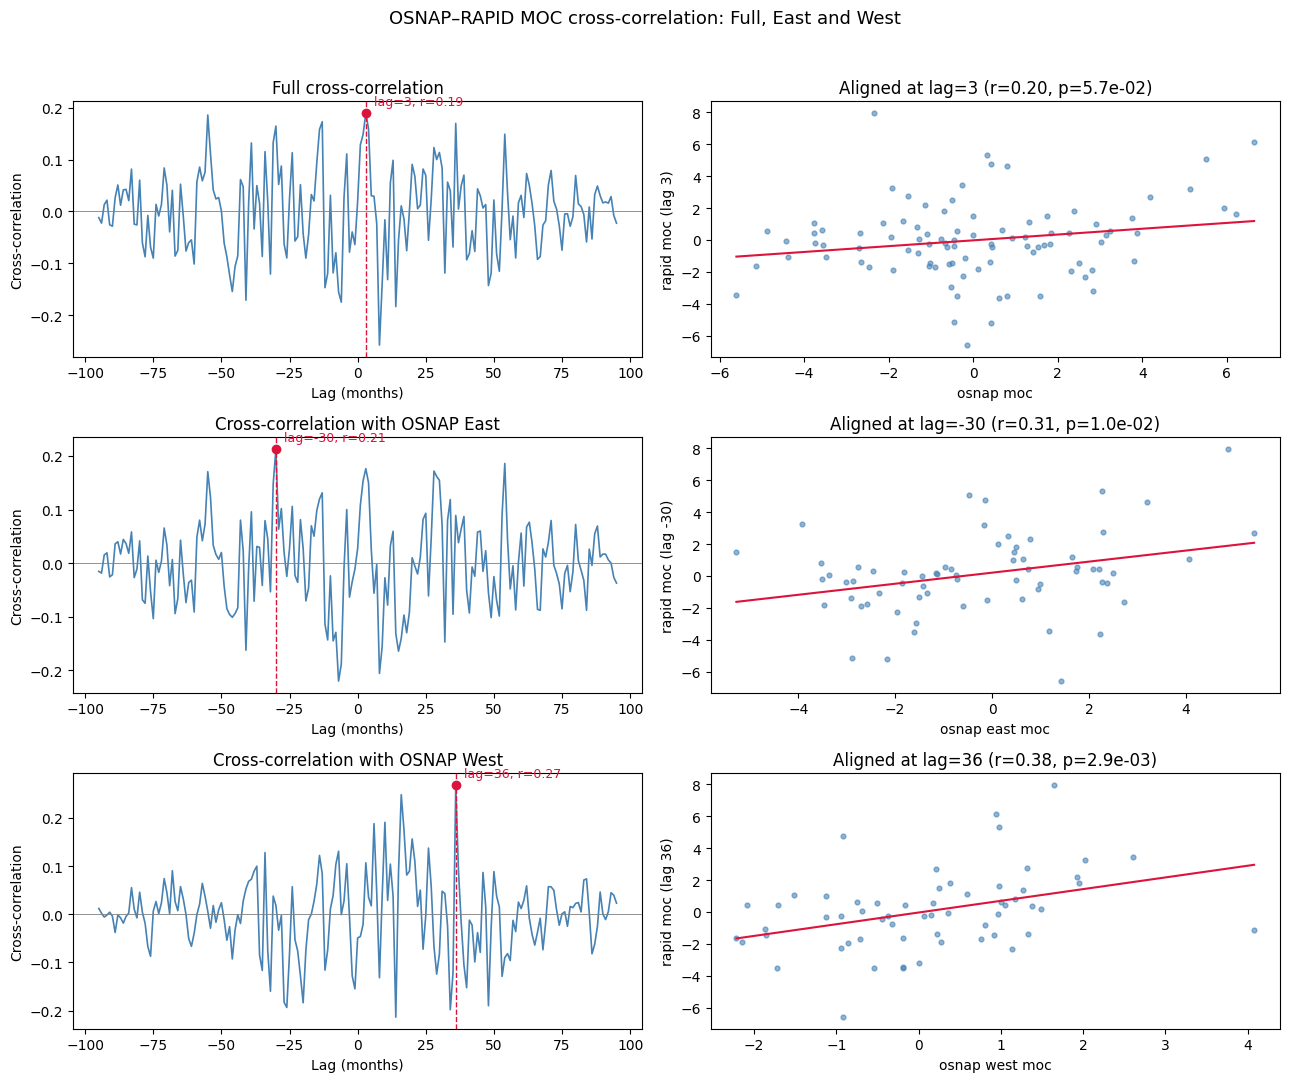

In [144]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

correlation.plot_cc_panel(
    axes[0, 0],
    axes[0, 1],
    osnap_deseason_detr,
    rapid_deseason_detr,
    "Full cross-correlation",
    "osnap moc",
    "rapid moc",
)

correlation.plot_cc_panel(
    axes[1, 0],
    axes[1, 1],
    osnapeast_deseason_detr,
    rapid_deseason_detr,
    "Cross-correlation with OSNAP East",
    "osnap east moc",
    "rapid moc",
)
correlation.plot_cc_panel(
    axes[2, 0],
    axes[2, 1],
    osnapwest_deseason_detr,
    rapid_deseason_detr,
    "Cross-correlation with OSNAP West",
    "osnap west moc",
    "rapid moc",
)
fig.suptitle("OSNAP–RAPID MOC cross-correlation: Full, East and West", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(
    "../figures/osnap_rapid_moc_cross_correlation_deseason_detrend_east_west.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

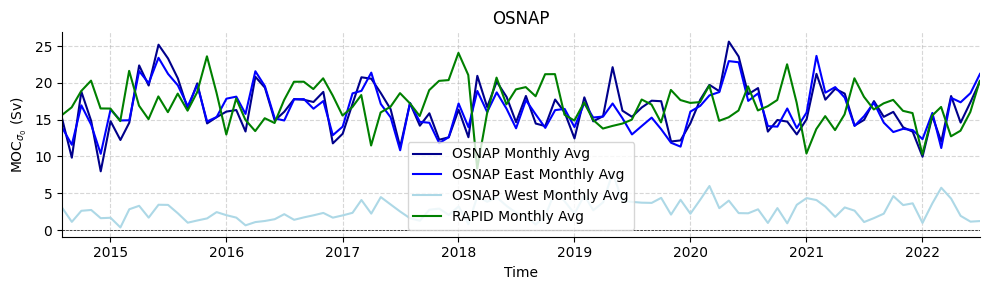

In [145]:
amocatlas.plotters.plot_amoc_timeseries(
    data=[osnap, osnap, osnap, rapid],
    varnames=["MOC_SIGMA0", "MOC_EAST_SIGMA0", "MOC_WEST_SIGMA0", "MOC"],
    labels=["OSNAP", "OSNAP East", "OSNAP West", "RAPID"],
    colors=["darkblue", "blue", "lightblue", "green"],
    resample_monthly=True,
    plot_raw=False,
    title="OSNAP",
)
plt.xlim([osnap.TIME.values[0], osnap.TIME.values[-1]])
plt.savefig(
    "../figures/osnap_rapid_moc_timeseries-new.png", dpi=300, bbox_inches="tight"
)